In [1]:
import numpy as np
from docutils.nodes import warning

from probabilistic_models.opearations.demand_sampler import simple_demand_sampler

import pandapower as pp
import pandapower.networks as pp_net
import numpy as np

import seaborn as sb
import pandas as pd

In [2]:
def apply_planned_outage_cluster(net, outaged_lines):
    NET = net.deepcopy()
    for idx in outaged_lines:
        if idx in net.line.index:
            NET.line.at[idx,'in_service'] = False
    return NET

In [3]:
def run_MC(net,  load_scenarios, base_load =None, outage_set = None):
    if base_load is not None:
        net.load['p_mw'] = base_load

    if outage_set is not None:

            for type, idx in outage_set:
                try:
                    if type == 'line':
                        net.line.at[idx, 'in_service'] = False
                    if type == 'gen':
                        net.gen.at[idx, 'in_service'] = False
                    if type == 'trafo':
                        net.trafo.at[idx, 'in_service'] = False
                except:
                    print(f'type {type} not recognized')

    pp.runopp(net,calculate_voltage_angles=True, init='flat', delta=1e-8, verbose=False)
    net.gen['p_mw']  =      net.res_gen['p_mw']
    net.gen['vm_pu'] =      net.res_gen['vm_pu']
    #net.gen['q_mvar'] =     net.res_gen['q_mvar']
    net.gen['controllable'] = False

    results = []
    for i, p_mw in enumerate(load_scenarios):
        NET = net.deepcopy()

        try:
            NET.load['p_mw'] = p_mw
            pp.runpp(net,calculate_voltage_angles=True, init='flat', delta=1e-8, verbose=False)
            converged = True
            results.append({'scenario':i, 'converged':converged,
                            'res_line': NET.res_line.copy(), 'res_bus': NET.res_bus.copy(), 'res_gen':NET.res_gen.copy(),
                            'loading_percent': NET.res_line['loading_percent'], 'vm_pu': NET.res_gen['vm_pu'].values,
                            'ext_grid_p_mw': NET.res_ext_grid['p_mw'].values,
                            'max_vm_pu':NET.res_gen['vm_pu'].max(), 'min_vm_pu': NET.res_gen['vm_pu'].min(), 'max_loading': NET.res_line['loading_percent'].max() })
        except pp.powerflow.LoadflowNotConverged:
            converged = False
            results.append({'scenario':i, 'converged':converged,
                             'res_line': None, 'res_bus': None, 'res_gen':None,
                            'loading_percent':None, 'vm_pu': None, 'ext_grid_p_mw': None,
                            'max_vm_pu':None, 'min_vm_pu':None, 'max_loading': None })



In [4]:
net = pp_net.case24_ieee_rts()

In [5]:
net.gen

,name,bus,p_mw,vm_pu,sn_mva,min_q_mvar,max_q_mvar,scaling,slack,in_service,slack_weight,type,controllable,max_p_mw,min_p_mw
0,None,0,10.0,1.035,NaN,0.0,10.0,1.0,False,True,0.0,None,True,20.0,16.0
1,None,1,10.0,1.035,NaN,0.0,10.0,1.0,False,True,0.0,None,True,20.0,16.0
2,None,6,80.0,1.025,NaN,0.0,60.0,1.0,False,True,0.0,None,True,100.0,25.0
3,None,13,0.0,0.980,NaN,-50.0,200.0,1.0,False,True,0.0,None,True,0.0,0.0
4,None,14,12.0,1.014,NaN,0.0,6.0,1.0,False,True,0.0,None,True,12.0,2.4
5,None,15,155.0,1.017,NaN,-50.0,80.0,1.0,False,True,0.0,None,True,155.0,54.3
6,None,17,400.0,1.050,NaN,-50.0,200.0,1.0,False,True,0.0,None,True,400.0,100.0
7,None,20,400.0,1.050,NaN,-50.0,200.0,1.0,False,True,0.0,None,True,400.0,100.0
8,None,21,50.0,1.050,NaN,-10.0,16.0,1.0,False,True,0.0,None,True,50.0,10.0
9,None,22,155.0,1.050,NaN,-50.0,80.0,1.0,False,True,0.0,None,True,155.0,54.3


In [6]:
pp.runopp(net,calculate_voltage_angles=True, init='flat', delta=1e-8, verbose=False)
net.res_gen


,p_mw,q_mvar,va_degree,vm_pu
0,1.600000e+01,6.504938,-7.396246,1.020960
1,1.600000e+01,6.279901,-7.476162,1.020857
2,7.160779e+01,59.999909,-10.340734,1.003281
3,-3.536253e-09,162.410396,0.913462,1.048407
4,2.400001e+00,5.999936,9.351030,1.036350
5,1.550000e+02,79.999890,8.518352,1.043801
6,4.000000e+02,74.147484,14.245042,1.050000
7,4.000000e+02,12.460924,15.027655,1.050000
8,5.000000e+01,-1.384972,20.690759,1.050000
9,1.550000e+02,51.602570,9.669246,1.050000


In [7]:
mean_demand_value = net.load['p_mw'].values
Load_samples = simple_demand_sampler(mean_demand_value,   n_samples= 1000,  noise_level = 0.01, fat_tailed = True)

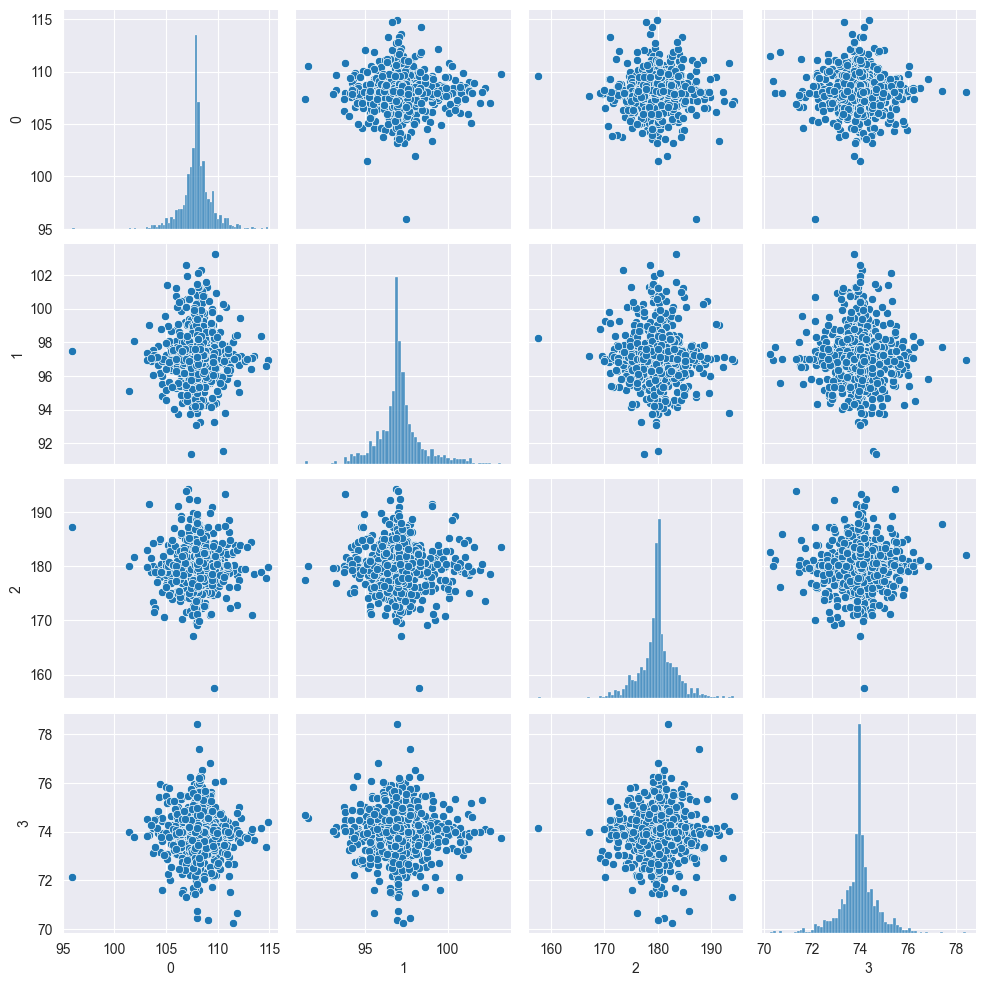

In [8]:
sb.pairplot(pd.DataFrame(Load_samples).iloc[:,:4])

In [9]:
highest_load = Load_samples[np.argmax(np.sum(Load_samples,axis=1))]
lowest_load = Load_samples[np.argmin(np.sum(Load_samples,axis=1))]
Load_scenarios =[lowest_load, mean_demand_value, highest_load]

In [10]:
pp.runopp(net,calculate_voltage_angles=True, init='flat', delta=1e-8,verbose=False)
rating_opf = net.res_line.loading_percent


In [11]:
net.sgen

,name,bus,p_mw,q_mvar,sn_mva,scaling,in_service,type,current_source,controllable,max_p_mw,min_p_mw,max_q_mvar,min_q_mvar
0,None,0,10.0,0.0,NaN,1.0,True,,True,True,20.0,16.0,0.0,-10.0
1,None,0,76.0,0.0,NaN,1.0,True,,True,True,76.0,15.2,25.0,-30.0
2,None,0,76.0,0.0,NaN,1.0,True,,True,True,76.0,15.2,25.0,-30.0
3,None,1,10.0,0.0,NaN,1.0,True,,True,True,20.0,16.0,0.0,-10.0
4,None,1,76.0,0.0,NaN,1.0,True,,True,True,76.0,15.2,25.0,-30.0
5,None,1,76.0,0.0,NaN,1.0,True,,True,True,76.0,15.2,25.0,-30.0
6,None,6,80.0,0.0,NaN,1.0,True,,True,True,100.0,25.0,0.0,-60.0
7,None,6,80.0,0.0,NaN,1.0,True,,True,True,100.0,25.0,0.0,-60.0
8,None,12,95.1,0.0,NaN,1.0,True,,True,True,197.0,69.0,0.0,-80.0
9,None,12,95.1,0.0,NaN,1.0,True,,True,True,197.0,69.0,0.0,-80.0


In [12]:
net.res_ext_grid

,p_mw,q_mvar
0,77.767697,64.905459


In [13]:
pp.runpp(net)
rating_pf = net.res_line.loading_percent
net.res_ext_grid


,p_mw,q_mvar
0,-1.427347,104.128331


In [14]:
NET = apply_planned_outage_cluster(net, [6,7,8])
pp.runpp(NET)
rating_pf_outage2 = NET.res_line.loading_percent

C:\Users\roberto.rocchetta\AppData\Local\Temp\ipykernel_38824\3152203071.py:2: DeprecationWarning: Use copy.deepcopy(net) instead of net.deepcopy()
  NET = net.deepcopy()


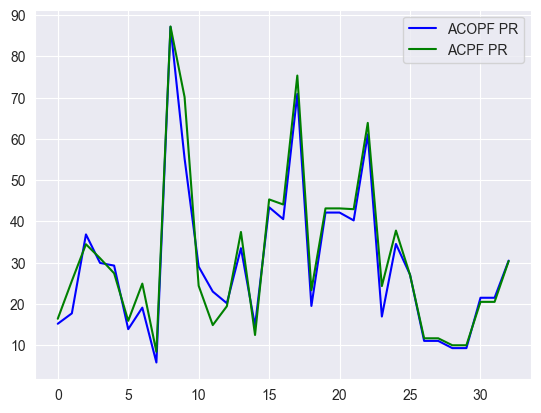

In [15]:
import matplotlib.pyplot as plt
plt.plot(rating_opf, c='b', label='ACOPF PR')
plt.plot(rating_pf, c='g', label='ACPF PR')
#plt.plot(rating_pf_outage2, c='r', label='ACPF PR outage line 2')
plt.legend()
plt.show()

In [16]:

def run_based_opf(net, p_load, q_load):
    NET = net.deepcopy()
    NET.load['p_mw'] = p_load
    NET.load['q_mvar'] = q_load

    try:
        pp.runopp(NET,calculate_voltage_angles=True, init='flat', delta=1e-8,verbose=False)
        resulting_dispatch = {"gen_p": NET.res_gen["p_mw"].values.copy() ,
                              "ext_p":NET.res_ext_grid["p_mw"].values.copy(),
                              "vm_pu":NET.res_bus["vm_pu"].values.copy()}
        return NET, resulting_dispatch, True

    except Exception:
        return NET, None, False


In [17]:
NET, resulting_dispatch, solved = apply_planned_outage_cluster(net, [1, 3])

C:\Users\roberto.rocchetta\AppData\Local\Temp\ipykernel_38824\3152203071.py:2: DeprecationWarning: Use copy.deepcopy(net) instead of net.deepcopy()
  NET = net.deepcopy()


ValueError: too many values to unpack (expected 3)